In [82]:
import numpy as np
import pandas as pd

# !pip install ucimlrepo
# !pip install pytorch-tabnet
# !pip install pytorch-tabular

In [83]:
import warnings

warnings.filterwarnings("ignore")

For this project, I chose a Tabular dataset which fitted the criteria of a **Classification** task:

Covertype
---

 - Source: https://archive.ics.uci.edu/dataset/31/covertype
 - Classifies pixels from forest imagery into 7 types: <br/>
        - spruce/fir            <br/>
        - Lodgepole Pine        <br/>
        - Ponderosa Pine        <br/>
        - Cottonwood/Willow     <br/>
        - Aspen                 <br/>
        - Douglas-fir           <br/>
        - Krummholz             <br/>

  - Has 54 original features. Features like: soil type, elevation, vertical distance to hidrology.

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
covertype = fetch_ucirepo(id=31)

# data (as pandas dataframes)
X = covertype.data.features
y = covertype.data.targets['Cover_Type']

# variable information
print(covertype.variables)

### Feature Engineering

**Elevation to Hydrology Ratio** ===> Trees that are not near rivers/creeks are different than those which are, at same elevation.
<br/>
**Terrain roughness** ===> Slope * Elevation

In [85]:
X["Elevation_to_Hydrology_Ratio"] = (
    X["Elevation"] /
    (X["Horizontal_Distance_To_Hydrology"] + 1)
)
X["Terrain_Roughness"] = (
    X["Elevation"] * X["Slope"]
)

### Feature Engineering

Since Aspect (angle to azimuth) is withing 0-360, I thought that it would help the model to convert these value to [-1, 1], using **sin** and **cos**.

In [86]:
X["Aspect_sin"] = np.sin(np.radians(X["Aspect"]))
X["Aspect_cos"] = np.cos(np.radians(X["Aspect"]))
X.drop(columns=["Aspect"])

,Elevation,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area1,...,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Elevation_to_Hydrology_Ratio,Terrain_Roughness,Aspect_sin,Aspect_cos
0,2596,3,258,0,510,221,232,148,6279,1,...,0,0,0,0,0,0,10.023166,7788,0.777146,0.629320
1,2590,2,212,-6,390,220,235,151,6225,1,...,0,0,0,0,0,0,12.159624,5180,0.829038,0.559193
2,2804,9,268,65,3180,234,238,135,6121,1,...,0,0,0,0,0,0,10.423792,25236,0.656059,-0.754710
3,2785,18,242,118,3090,238,238,122,6211,1,...,0,0,0,0,0,0,11.460905,50130,0.422618,-0.906308
4,2595,2,153,-1,391,220,234,150,6172,1,...,0,0,0,0,0,0,16.850649,5190,0.707107,0.707107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581007,2396,20,85,17,108,240,237,118,837,0,...,0,0,0,0,1,0,27.860465,47920,0.453990,-0.891007
581008,2391,19,67,12,95,240,237,119,845,0,...,0,0,0,0,1,0,35.161765,45429,0.469472,-0.882948
581009,2386,17,60,7,90,236,241,130,854,0,...,0,0,0,0,1,0,39.114754,40562,0.358368,-0.933580
581010,2384,15,60,5,90,230,245,143,864,0,...,0,0,0,0,1,0,39.081967,35760,0.173648,-0.984808


In [87]:
print(X.shape)
print(y.shape)

(581012, 58)
(581012,)


#### Number of classes:

In [88]:
len(set(y))

7

#### Criteria for metric selection on classification tasks is how balanced the dataset is. In our case, the difference in the number of instances between classes <br/> is major, thus, metrics like 'Macro-Averaged F1-Score' and 'Multi-class ROC-AUC' may be advantageous for showing poor performance for minority classes.

#### For better coverage, 'Cohen's Kappa' and 'Balanced accuracy' are also selected.

In [89]:
for _type in range(1, len(set(y))):
    print(sum(n == _type for n in y))

211840
283301
35754
2747
9493
17367


In [90]:
from sklearn.metrics import classification_report, f1_score, roc_auc_score, balanced_accuracy_score, cohen_kappa_score

def evaluation(y_val, y_pred, y_proba):

    print(classification_report(y_val, y_pred))

    return {
        'macro_f1_score': f1_score(y_val, y_pred, average='macro'),
        'roc_auc_score': roc_auc_score(y_val, y_proba, multi_class='ovr', average='macro'),
        'balanced_accuracy_score': balanced_accuracy_score(y_val, y_pred),
        'cohen_kappa_score': cohen_kappa_score(y_val, y_pred),
    }

#### Train-test split section

Added stratification, due to high imbalance in class sizes.
Added also validation set, as the F-T Transformer expects a validation split to rationalize on during training (for convergence).

In [91]:
from sklearn.model_selection import train_test_split

#           train+val         test
# [===========80%==========|===20%===]
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42,
    stratify=y
)

#           train             val
# [==========75%=========|====25%====]
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42,
    stratify=y_train_val
)

# Final result:
#         train         val     test
# [========60%=======|==%20==|==%20==]

### Selection of smaller models
#### --- The selection will be done using Chi2 (Chi-squared statistical test, using SelectKBest applied on the batch of features).

#### In order for chi2-selection to work, X's values must be positive. This can be achieved using MinMaxScaler.

In [92]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_scaled

array([[0.36868434, 0.14166667, 0.04545455, ..., 0.0380125 , 0.88857298,
        0.8146602 ],
       [0.36568284, 0.15555556, 0.03030303, ..., 0.02528309, 0.91451879,
        0.77959645],
       [0.47273637, 0.38611111, 0.13636364, ..., 0.12317454, 0.82802951,
        0.12264521],
       ...,
       [0.26363182, 0.44166667, 0.25757576, ..., 0.1979793 , 0.67918397,
        0.03320979],
       [0.26263132, 0.47222222, 0.22727273, ..., 0.17454119, 0.58682409,
        0.00759612],
       [0.26213107, 0.45833333, 0.1969697 , ..., 0.15120558, 0.62940952,
        0.01703709]], shape=(581012, 58))

In [93]:
from sklearn.feature_selection import SelectKBest, chi2

chi_selections = []

for k in range(10, 54, 5):
    chi2_selector = SelectKBest(score_func=chi2, k=k)

    X_kbest = chi2_selector.fit_transform(X_scaled, y)

    selected_features = chi2_selector.get_support(indices=True)

    chi_selections.append(selected_features)

chi_selections.append([x for x in range(len(X.columns))])

In [94]:
feature_names = X.columns
smallest_model_feature_names = feature_names[chi_selections[0]]

smallest_model_feature_names

Index(['Wilderness_Area1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4',
       'Soil_Type6', 'Soil_Type10', 'Soil_Type38', 'Soil_Type39',
       'Soil_Type40', 'Wilderness_Area4'],
      dtype='object')

Function to generate the model

In [95]:
from pytorch_tabular import TabularModel
from pytorch_tabular.models import FTTransformerConfig
from pytorch_tabular.config import DataConfig, TrainerConfig, OptimizerConfig

def gen_fttransformer(features):
    data_config = DataConfig(
        target=['Cover_Type'],
        continuous_cols=features,
        categorical_cols=[]
    )

    trainer_config = TrainerConfig(
        batch_size=1024,
        max_epochs=15,
        accelerator="gpu",
        early_stopping="valid_loss",
        early_stopping_patience=3
    )

    optimizer_config = OptimizerConfig()

    mode_config = FTTransformerConfig(
        task='classification',
        num_heads=4,
        num_attn_blocks=2,
        learning_rate=1e-3
    )

    tabular_model = TabularModel(
        data_config=data_config,
        model_config=mode_config,
        optimizer_config=optimizer_config,
        trainer_config=trainer_config,
    )

    return tabular_model


The FT Transformer takes a long time to train. GPU setup was needed.

In [96]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


Function to train each model on its specific selection of features (done using chi2 + SelectKBest). Metrics and predictions are stored for later usage.

In [97]:
y_preds = []
y_probas = []
evaluation_dicts = []

for chi_selection in chi_selections:
  current_features = list(feature_names[chi_selection])
  print("No. features: " + str(len(current_features)))

  X_train_selected = X_train[current_features].copy()
  train_df = X_train_selected
  train_df['Cover_Type'] = y_train

  val_df = X_val[current_features].copy()
  val_df["Cover_Type"] = y_val

  ft_transformer = gen_fttransformer(features=current_features)

  ft_transformer.fit(
      train=train_df,
      validation=val_df
  )

  X_test_selected = X_test[current_features]
  test_df = X_test_selected.copy()
  test_df['Cover_Type'] = y_test

  predictions = ft_transformer.predict(X_test)

  proba_cols = [c for c in predictions.columns if c.endswith('_probability')]
  y_proba = predictions[proba_cols].to_numpy()

  y_pred = predictions['Cover_Type_prediction']

  y_preds.append({ len(current_features) : y_pred })
  y_probas.append({ len(current_features) : y_proba })
  evaluation_dicts.append({ len(current_features) : evaluation(y_test, y_pred, y_proba) })

2026-05-30 23:15:39,430 - {pytorch_tabular.tabular_model:145} - INFO - Experiment Tracking is turned off


No. features: 10


Seed set to 42
2026-05-30 23:15:39,589 - {pytorch_tabular.tabular_model:547} - INFO - Preparing the DataLoaders
2026-05-30 23:15:39,741 - {pytorch_tabular.tabular_datamodule:527} - INFO - Setting up the datamodule for classification task
2026-05-30 23:15:40,465 - {pytorch_tabular.tabular_model:598} - INFO - Preparing the Model: FTTransformerModel
2026-05-30 23:15:40,636 - {pytorch_tabular.tabular_model:341} - INFO - Preparing the Trainer
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-05-30 23:15:40,791 - {pytorch_tabular.tabular_model:677} - INFO - Training Started
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ _backbone        │ FTTransformerBackbone │ 57.7 K │ train │     0 │
│ 1 │ _embedding_layer │ Embedding2dLayer      │    660 │ train │     0 │
│ 2 │ _head            │ LinearHead            │    231 │ train │     0 │
│ 3 │ loss             │ CrossEntropyLoss      │      0 │ train │     0 │
└───┴──────────────────┴───────────────────────┴────────┴───────┴───────┘

Trainable params: 58.6 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 58.6 K                                                                                               
Total estimated model params size (MB): 0.234                                                                      
Modules in train mode: 50                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ _backbone        │ FTTransformerBackbone │ 57.8 K │ train │     0 │
│ 1 │ _embedding_layer │ Embedding2dLayer      │  3.6 K │ train │     0 │
│ 2 │ _head            │ LinearHead            │    231 │ train │     0 │
│ 3 │ loss             │ CrossEntropyLoss      │      0 │ train │     0 │
└───┴──────────────────┴───────────────────────┴────────┴───────┴───────┘

Trainable params: 61.6 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 61.6 K                                                                                               
Total estimated model params size (MB): 0.246                                                                      
Modules in train mode: 50                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=15` reached.


2026-05-31 00:37:22,039 - {pytorch_tabular.tabular_model:690} - INFO - Training the model completed
2026-05-31 00:37:22,041 - {pytorch_tabular.tabular_model:1531} - INFO - Loading the best model


              precision    recall  f1-score   support

           1       0.86      0.85      0.86     42368
           2       0.87      0.89      0.88     56661
           3       0.79      0.89      0.84      7151
           4       0.87      0.61      0.72       549
           5       0.72      0.54      0.62      1899
           6       0.68      0.64      0.66      3473
           7       0.88      0.85      0.87      4102

    accuracy                           0.86    116203
   macro avg       0.81      0.75      0.78    116203
weighted avg       0.86      0.86      0.86    116203



In [98]:
import pandas as pd

rows = []

for d in evaluation_dicts:
    n_features = next(iter(d))
    metrics = d[n_features]

    rows.append({
        "n_features": n_features,
        **metrics
    })

results_df = pd.DataFrame(rows)
results_df = results_df.sort_values("n_features")

results_df

,n_features,macro_f1_score,roc_auc_score,balanced_accuracy_score,cohen_kappa_score
0,10,0.305912,0.809289,0.356561,0.250738
1,15,0.392865,0.847161,0.409120,0.374502
2,20,0.501846,0.931142,0.482733,0.524639
3,25,0.634801,0.954953,0.593185,0.603723
4,30,0.704255,0.972027,0.669565,0.692431
5,35,0.735406,0.977719,0.711680,0.730084
6,40,0.757749,0.980568,0.729551,0.752684
7,45,0.769915,0.981805,0.740966,0.755945
8,50,0.794901,0.984331,0.768962,0.774215
9,54,0.776809,0.983096,0.752354,0.771480


In [99]:
results_df.sort_values(
    "macro_f1_score",
    ascending=False
)

,n_features,macro_f1_score,roc_auc_score,balanced_accuracy_score,cohen_kappa_score
8,50,0.794901,0.984331,0.768962,0.774215
9,54,0.776809,0.983096,0.752354,0.771480
7,45,0.769915,0.981805,0.740966,0.755945
6,40,0.757749,0.980568,0.729551,0.752684
5,35,0.735406,0.977719,0.711680,0.730084
4,30,0.704255,0.972027,0.669565,0.692431
3,25,0.634801,0.954953,0.593185,0.603723
2,20,0.501846,0.931142,0.482733,0.524639
1,15,0.392865,0.847161,0.409120,0.374502
0,10,0.305912,0.809289,0.356561,0.250738


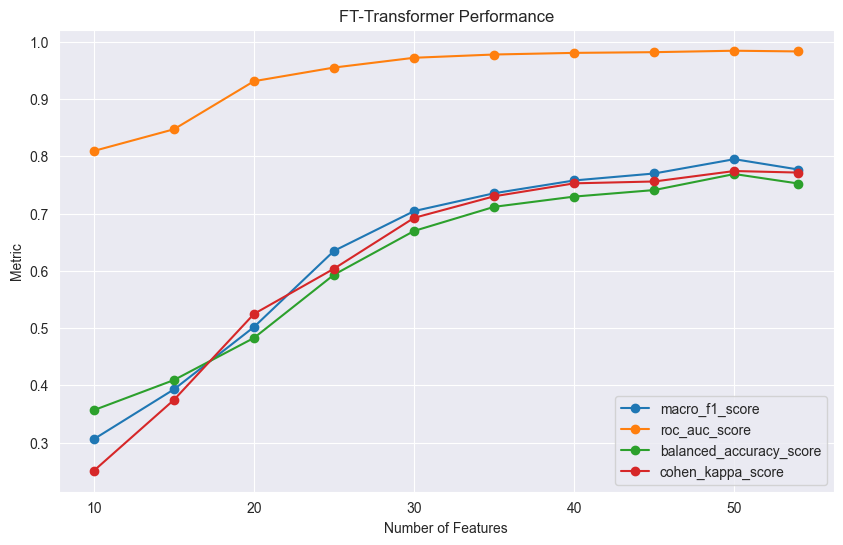

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for col in results_df.columns:
    if col != "n_features":
        plt.plot(
            results_df["n_features"],
            results_df[col],
            marker="o",
            label=col
        )

plt.grid(True)
plt.legend()
plt.xlabel("Number of Features")
plt.ylabel("Metric")
plt.title("FT-Transformer Performance")
plt.show()

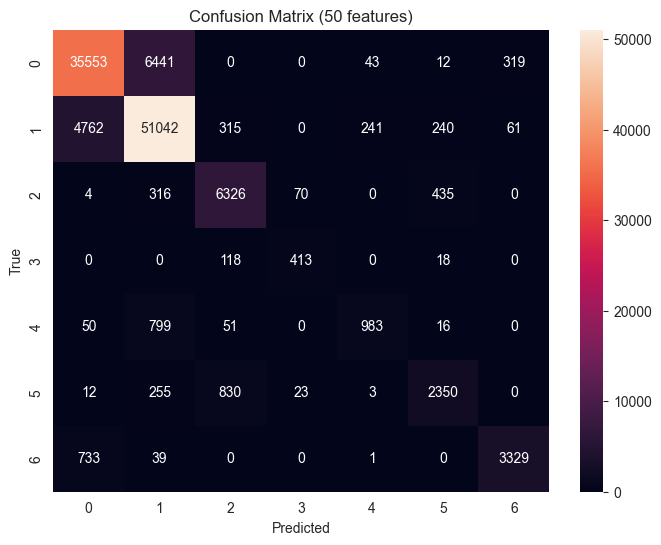

In [101]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

best_n = results_df.loc[
    results_df["macro_f1_score"].idxmax(),
    "n_features"
]

best_pred = None

for d in y_preds:
    if best_n in d:
        best_pred = d[best_n]
        break

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    f"Confusion Matrix ({best_n} features)"
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

In [102]:
from sklearn.metrics import balanced_accuracy_score

for d in y_preds:
    n_features = next(iter(d))
    pred = d[n_features]

    score = balanced_accuracy_score(
        y_test,
        pred
    )

    print(f"{n_features:2d} features -> balanced acc = {score:.4f}")

10 features -> balanced acc = 0.3566
15 features -> balanced acc = 0.4091
20 features -> balanced acc = 0.4827
25 features -> balanced acc = 0.5932
30 features -> balanced acc = 0.6696
35 features -> balanced acc = 0.7117
40 features -> balanced acc = 0.7296
45 features -> balanced acc = 0.7410
50 features -> balanced acc = 0.7690
54 features -> balanced acc = 0.7524


In [103]:
from sklearn.metrics import classification_report

recalls = []

for d in y_preds:
    n_features = next(iter(d))
    pred = d[n_features]

    report = classification_report(
        y_test,
        pred,
        output_dict=True
    )

    row = {"n_features": n_features}

    for cls in range(1,8):
        row[f"class_{cls}"] = report[str(cls)]["recall"]

    recalls.append(row)

recall_df = pd.DataFrame(recalls)
recall_df = recall_df.sort_values("n_features")

recall_df

,n_features,class_1,class_2,class_3,class_4,class_5,class_6,class_7
0,10,0.069510,0.969309,0.886170,0.000000,0.000000,0.000000,0.570941
1,15,0.360036,0.865569,0.907006,0.160291,0.000000,0.000000,0.570941
2,20,0.713227,0.763294,0.847014,0.355191,0.022117,0.159516,0.518771
3,25,0.736664,0.817582,0.824220,0.500911,0.328594,0.344371,0.599951
4,30,0.784885,0.872470,0.853447,0.664845,0.361243,0.396775,0.753291
5,35,0.814081,0.873370,0.845896,0.581056,0.365982,0.660812,0.840566
6,40,0.818377,0.896454,0.891763,0.684882,0.369142,0.617622,0.828620
7,45,0.818849,0.904485,0.843798,0.744991,0.408636,0.632018,0.833983
8,50,0.839147,0.900831,0.884632,0.752277,0.517641,0.676648,0.811555
9,54,0.848140,0.888689,0.885051,0.608379,0.542391,0.644976,0.848854
